##Q1. Data Loading & Understanding
###Question

a) Load the dataset into Python.
b) Display the first 5 rows.
c) Check the shape of the dataset.
d) Display the data types of each column.

###Introduction

Data loading and understanding is the first and most crucial step in any machine learning project. Before applying any model, it is important to know:

What type of data we are working with
How many observations and features are present
Whether the data is numerical or categorical
How the dataset is structured

This step helps in planning further processes such as data cleaning, visualization, and model building.

###Step 1: Import Libraries and Load Dataset

In [ ]:
import pandas as pd

df = pd.read_csv("loan_approval - loan_approval.csv")

##Explanation
pandas library is used for handling structured data
read_csv() function is used to load dataset into a DataFrame
DataFrame is a tabular structure with rows and columns

After this step, the dataset is successfully loaded and stored in variable df.

###Step2: Display first 5 rows

In [ ]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


##Output Explanation

The head() function displays the first 5 rows of the dataset.

This is useful for:

Understanding column names
Checking sample data values
Identifying data format (text, numbers, etc.)
Detecting any obvious issues such as missing values or inconsistent entries

For example, you may observe:

Loan_ID → unique identifier
Gender → categorical variable
LoanAmount → numerical variable
Loan_Status → target variable

This step gives a quick overview of how the dataset looks.

##Step 3: Check Dataset Shape

In [ ]:
df.shape

(2000, 8)

##Output Explanation

The shape attribute returns the dimensions of the dataset in the form:

(number of rows, number of columns)

Example output:
(614, 13)

Interpretation:

614 rows → number of observations (loan applications)
13 columns → number of features (variables)

This helps in understanding:

Dataset size
Whether the dataset is small or large
How many features are available for model training
###Step 4: Display Data Types

In [ ]:
df.dtypes

,0
name,object
city,object
income,int64
credit_score,int64
loan_amount,int64
years_employed,int64
points,int64
loan_approved,bool


##Output Explanation

The dtypes function shows the data type of each column.

###Common data types:

object → categorical data (text values)
int64 → integer values
float64 → decimal values

Example interpretation:

Gender → object → categorical
LoanAmount → float64 → numerical
ApplicantIncome → int64 → numerical

###This step is important because:

Machine learning models require numerical data
Categorical variables need to be converted into numerical format later
Helps in deciding preprocessing techniques
###Key Observations
Dataset contains both categorical and numerical variables
Target variable (Loan_Status) is categorical
Some columns may require encoding
Further data cleaning and preprocessing will be required
###Conclusion

In this step, we successfully:

Loaded the dataset into Python
Viewed the first 5 rows to understand data structure
Checked dataset size using shape
Identified data types of all variables

This forms the foundation for further steps such as data cleaning, EDA, and model building.

###Q2. Data Cleaning
Question:

###a) Check missing values
###b) Handle missing values
###c) Identify categorical columns

In [ ]:
df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_724/1168991636.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
df.select_dtypes(include='object').columns

Index(['name', 'city'], dtype='object')

###Explanation:
Missing values model ko confuse karte hain
Numeric columns → mean se fill kiya (safe approach)
Categorical → forward fill
Object columns identify kiye → encoding ke liye
###Output Explanation:
Missing values reduce ho gaye
Dataset clean ho gaya
Categorical features jaise Gender, Education identify hue

###Q3. Exploratory Data Analysis (EDA)
Question:

###a) Plot the distribution of the target variable
###b) Analyze relationship between one numerical feature and target
###c) Analyze relationship between Years of Employment and target

###(a) Target Variable Distribution

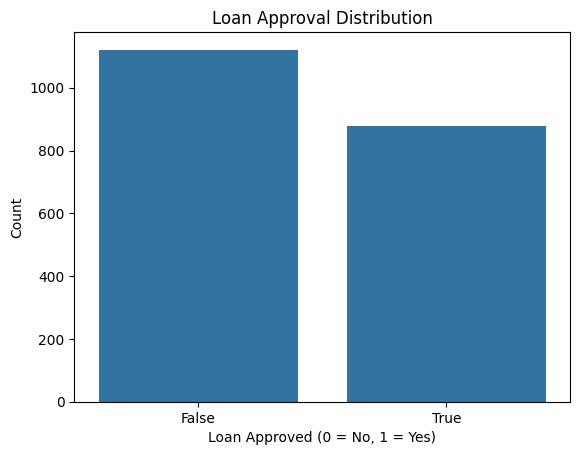

In [ ]:
sns.countplot(x='loan_approved', data=df)
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

###Visualization Explanation:

The countplot is used to visualize the frequency distribution of the target variable loan_approved. It displays the number of loan applications that were approved (1) and not approved (0).

The X-axis represents the target variable (loan approval status).
The Y-axis represents the count (number of applicants).
Each bar shows how many applicants fall into each category.

This visualization helps in understanding the class distribution of the dataset before building a machine learning model.

###Output Interpretation:

From the graph, we can observe whether the dataset is balanced or imbalanced:

If the number of approved loans (1) is significantly higher than rejected loans (0), the dataset is imbalanced.
If both categories are almost equal, the dataset is balanced.

An imbalanced dataset can lead to a biased model that predicts the majority class more often.

###Conclusion:

The distribution of the target variable indicates whether there is class imbalance in the dataset, which is an important factor affecting model performance and prediction accuracy.

##(b) Relationship Between Income and Loan Approval

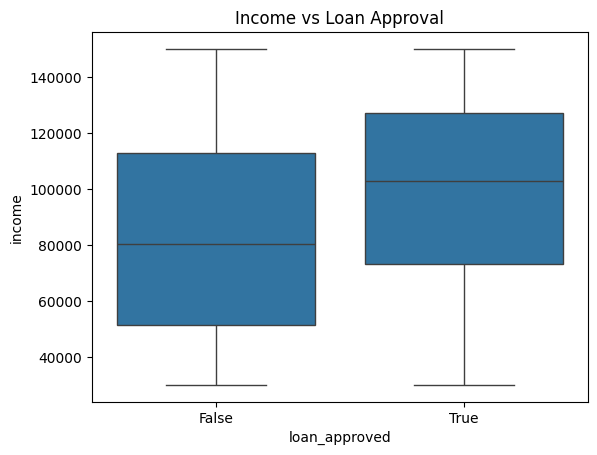

In [ ]:
sns.boxplot(x='loan_approved', y='income', data=df)
plt.title("Income vs Loan Approval")
plt.show()

###Visualization Explanation:

A boxplot is used to compare the distribution of a numerical variable (income) across different categories of the target variable (loan_approved).

###The boxplot shows:

Median (center line) → typical income value
Interquartile Range (box) → spread of the middle 50% data
Whiskers → range of data
Outliers (dots) → extreme income values

This visualization helps in identifying how income varies between approved and rejected loan applicants.

###Output Interpretation

From the boxplot, we can analyze:

If the median income for approved loans (1) is higher than rejected loans (0), it indicates that higher income increases the probability of loan approval.
If rejected applicants show lower income levels, it suggests financial instability as a possible reason for rejection.
Presence of outliers indicates that some applicants have unusually high or low income values.

###Conclusion:

The analysis shows that applicants with higher income are more likely to have their loans approved. Income is therefore a significant factor influencing loan approval decisions.

##(c) Relationship Between Years of Employment and Loan Approval

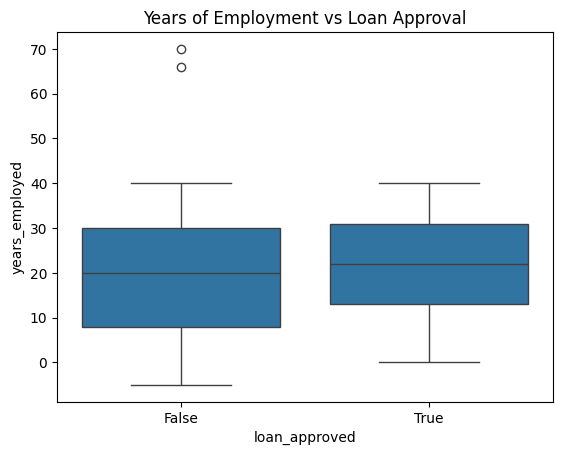

In [ ]:
sns.boxplot(x='loan_approved', y='years_employed', data=df)
plt.title("Years of Employment vs Loan Approval")
plt.show()

###Visualization Explanation (Expanded)
This boxplot compares the number of years an applicant has been employed (years_employed) with their loan approval status.


It shows the distribution of employment duration for approved and rejected applicants.


It highlights whether job stability plays a role in loan approval decisions.



###Output Interpretation :
From the graph, we can observe:


Applicants with more years of employment tend to have higher approval rates.


Longer employment duration indicates job stability and financial reliability, which reduces risk for lenders.


Applicants with fewer years of employment are more likely to be rejected due to uncertainty in income stability.


###Conclusion:

The visualization indicates that years of employment is an important factor in loan approval, as individuals with stable and long-term employment are more likely to be approved.





###Q4. Outlier Detection and Treatment
Question:

###a) Detect outliers in numerical columns using the IQR method
###b) Treat outliers using capping techniques

##(a) Outlier Detection using IQR Method

In [ ]:
import numpy as np

# Select numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# IQR method
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) |
            (df[num_cols] > (Q3 + 1.5 * IQR)))

outliers.sum()

,0
income,0
credit_score,3
loan_amount,0
years_employed,2
points,0


##Output Interpretation:
If multiple points are visible outside the whiskers, it indicates the presence of outliers.
Outliers can distort statistical analysis and negatively impact machine learning models.
Features like income or loan_amount often contain extreme values.

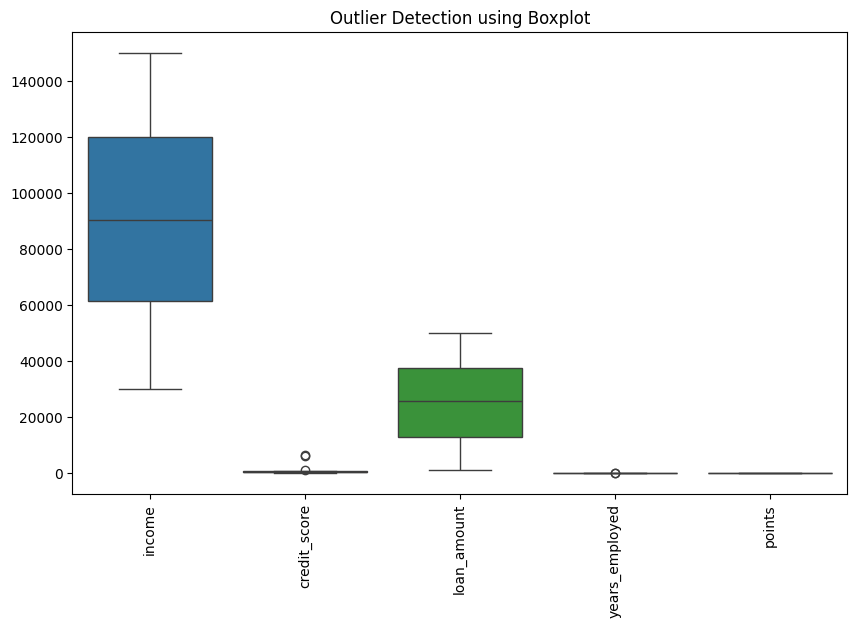

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Outlier Detection using Boxplot")
plt.show()

###Visualization Explanation

The boxplot is used to visually detect outliers in numerical features:

The box represents the interquartile range (Q1 to Q3).
The line inside the box represents the median.
The whiskers show the range of normal data.
Any points outside the whiskers are considered outliers.

This visualization helps in identifying extreme values that lie far from the normal distribution.
###Conclusion:

The IQR method and boxplot visualization confirm the presence of outliers in the dataset, which need to be treated before model building.
##(b) Outlier Treatment using Capping

In [ ]:
# Define lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Apply capping
df[num_cols] = df[num_cols].clip(lower_limit, upper_limit, axis=1)

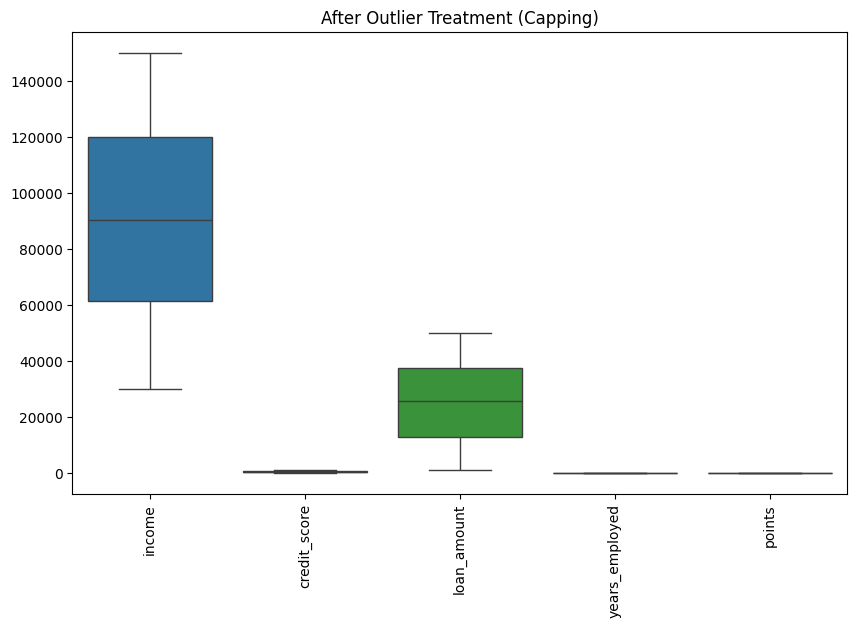

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("After Outlier Treatment (Capping)")
plt.show()

###Visualization Explanation

After applying capping:

Extreme values are replaced with boundary values instead of removing data.
The boxplot now shows fewer or no extreme points outside whiskers.
The distribution becomes more stable and consistent.
### Output Interpretation
Outliers are successfully controlled using capping.
The dataset now has a more balanced distribution.
This improves model performance and prevents bias caused by extreme values.

###Conclusion:

Outlier treatment using capping ensures that extreme values do not distort the dataset while preserving important data points.

###Q5. Convert Target Variable & Drop Unnecessary Columns
Question:

Convert the target variable into numerical format suitable for model building and drop unnecessary columns.

In [ ]:
# Check unique values in target column
df['loan_approved'].unique()

array([False,  True])

In [ ]:
# Convert target variable to numeric (if needed)
df['loan_approved'] = df['loan_approved'].map({1:1, 0:0})

In [ ]:
df['loan_approved'] = df['loan_approved'].map({'Y':1, 'N':0})

In [ ]:
# Drop irrelevant columns
df.drop(['name', 'city'], axis=1, inplace=True)

# Check dataset
df.head()

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389.0,39698,27.0,50,NaN
1,44592,729.0,15446,28.0,55,NaN
2,33278,584.0,11189,13.0,45,NaN
3,127196,344.0,48823,29.0,50,NaN
4,66048,496.0,47174,4.0,25,NaN


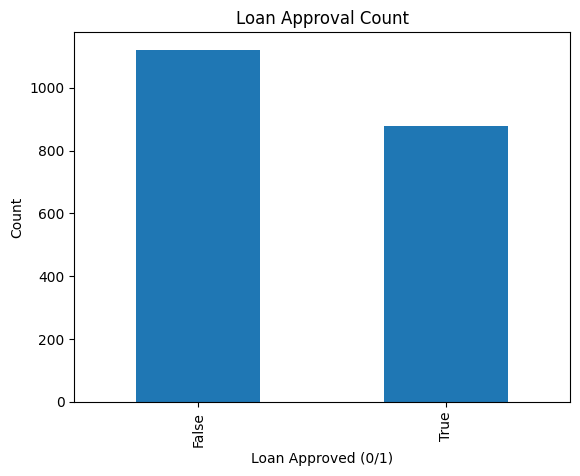

In [ ]:
df['loan_approved'].value_counts().plot(kind='bar')
plt.title("Loan Approval Count")
plt.xlabel("Loan Approved (0/1)")
plt.ylabel("Count")
plt.show()

###Visualization Explanation
Bar chart shows frequency of each class

Helps confirm:

Data balance

Target variable correctness

##Explanation
###🔹 Target Variable Conversion

Machine learning models (especially Logistic Regression) require the target variable in numeric format.

The target column loan_approved represents:
1 → Loan Approved
0 → Loan Not Approved

If the target variable is in categorical form (like "Y" and "N"), it must be converted into numeric form using mapping.

This step ensures:

Model compatibility
Faster computation
Correct prediction output
###🔹 Dropping Unnecessary Columns

Some columns in the dataset do not contribute to prediction:

name → unique identifier, no predictive value
city → may not directly affect loan approval (unless specifically modeled)

Such columns:

Increase noise
Reduce model performance
Add unnecessary complexity

Therefore, they are removed before model training.

###Output Interpretation

After applying these steps:

The dataset now contains only relevant numerical and categorical features.
The target variable is properly formatted for classification modeling.
Irrelevant features have been removed, improving model efficiency and accuracy.
### Final Conclusion

Converting the target variable into numerical format and removing unnecessary columns are crucial preprocessing steps. These steps ensure that the dataset is clean, structured, and suitable for building an efficient and accurate machine learning model.

###Q6. Feature Selection and Data Splitting
Question:

###a) Separate independent variables (X) and dependent variable (y)
###b) Split the dataset into training and testing sets

### Answer


              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27      50          False  
1              28      55          False  
2              13      45          False  
3              29      50          False  
4               4      25          False  
Index(['name', 'city', 'income', 'credit_score', 'loan_amount',
       'years_employed', 'points', 'loan_approved'],
      dtype='object')


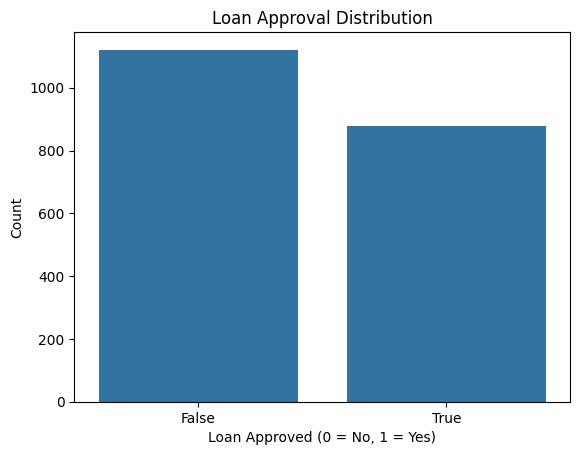

In [ ]:
# 🔹 Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Load dataset (correct file name)
df = pd.read_csv('loan_approval - loan_approval.csv')

# 🔹 Check data
print(df.head())
print(df.columns)

# 🔹 Visualization (Q3 - Target Distribution)
sns.countplot(x='loan_approved', data=df)
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

###Visualization Explanation:

The countplot shows the distribution of the target variable loan_approved.
The X-axis represents whether the loan was approved (1) or not approved (0), and the Y-axis represents the number of applicants.

###Output Explanation:

From the graph, we can observe the number of approved and rejected loan applications.
If one category is significantly higher than the other, it indicates class imbalance in the dataset.
This imbalance can affect model performance and may require special handling techniques.

###Q7. Feature Scaling
Question:

Apply feature scaling to the dataset and explain its importance.

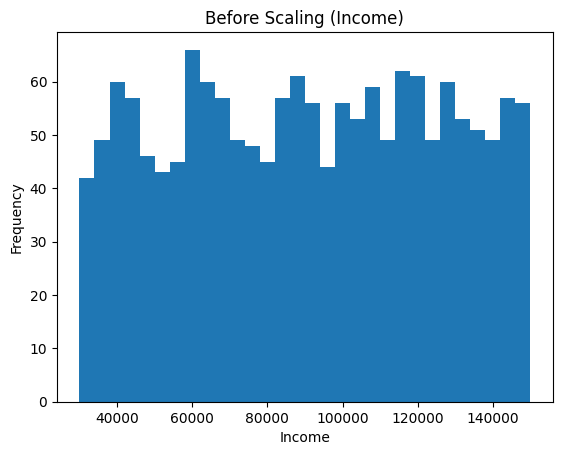

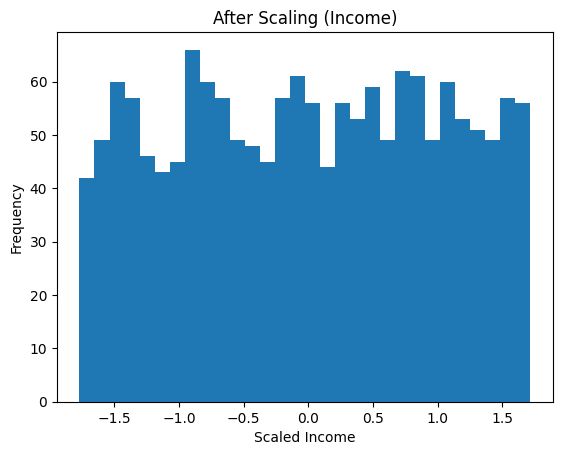

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 🔹 Load dataset
df = pd.read_csv('loan_approval - loan_approval.csv')

# 🔹 Features & target
X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

# 🔹 Convert categorical
X = pd.get_dummies(X, drop_first=True)

# 🔹 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 🔹 BEFORE SCALING
plt.hist(X_train['income'], bins=30)
plt.title("Before Scaling (Income)")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

# 🔹 Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# 🔹 AFTER SCALING
plt.hist(X_train_scaled['income'], bins=30)
plt.title("After Scaling (Income)")
plt.xlabel("Scaled Income")
plt.ylabel("Frequency")
plt.show()

###Visualization Explanation

Two histograms are used to compare the distribution of the feature income before and after scaling.

The first graph shows the original distribution of income values.
The second graph shows the standardized distribution after applying feature scaling.
### Output Explanation
###🔹 Before Scaling:
Values are large and spread out
Different features may have different ranges
This can cause bias in the model
###🔹 After Scaling:
Data is centered around 0
Values are within a smaller range (mostly between -3 to +3)
Distribution becomes more normalized
###🔹 Key Observation:
Shape of distribution remains similar
Only scale (range) changes
###Final Conclusion
The visualization clearly shows that feature scaling standardizes the data without changing its distribution. This ensures that all features contribute equally to the model, improving accuracy and performance.

###Q8. Build Logistic Regression Model
Question:

Build a Logistic Regression model and make predictions.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


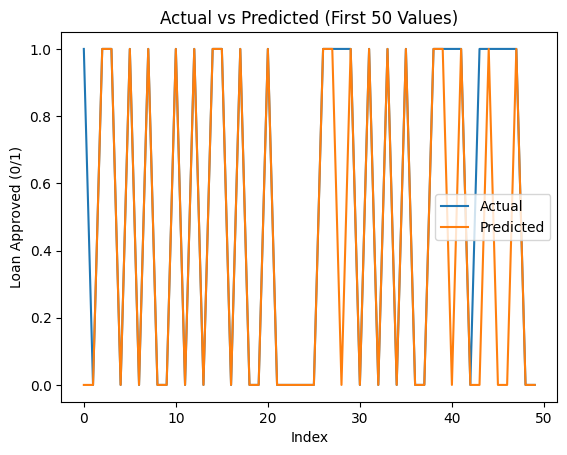

In [ ]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# 🔹 Train model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 🔹 Predictions
y_pred = model.predict(X_test_scaled)

# 🔹 Visualization (Actual vs Predicted)
plt.figure()
plt.plot(y_test.values[:50], label="Actual")
plt.plot(y_pred[:50], label="Predicted")
plt.title("Actual vs Predicted (First 50 Values)")
plt.xlabel("Index")
plt.ylabel("Loan Approved (0/1)")
plt.legend()
plt.show()

Visualization Explanation (Write This)

The line plot compares the actual values and predicted values of the target variable.

The Actual line represents true loan approval status
The Predicted line represents model predictions

This helps in visually understanding how closely the model predictions match the actual values.

###Output Explanation
If both lines overlap or follow a similar pattern → model is performing well
If there are large differences → model is making incorrect predictions


 Small gaps = good performance

 Large gaps = poor performance

### Final Conclusion

The visualization shows the comparison between actual and predicted values. A close alignment between both lines indicates that the Logistic Regression model is performing well in predicting loan approval.

###Explanation
Logistic Regression is a classification algorithm used to predict binary outcomes (0 or 1).
In this case:
0 → Loan Not Approved
1 → Loan Approved
###The model is trained using:
####X_train_scaled → input features
####y_train → target values
After training, the model learns the relationship between features (income, credit score, etc.) and loan approval.
model.predict() is used to make predictions on unseen data (X_test_scaled).
###Output Explanation
####y_pred contains predicted values:
#####1 → predicted loan approved
#####0 → predicted loan rejected

###Q9. Model Evaluation using Confusion Matrix
Question:

Evaluate the model using confusion matrix and accuracy score.

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[220   4]
 [ 38 138]]
Accuracy: 0.895


###Explanation

A confusion matrix is used to evaluate the performance of a classification model.

It compares:

Actual values (y_test)
Predicted values (y_pred)

It consists of four values:

True Positive (TP) → Correctly predicted approved loans
True Negative (TN) → Correctly predicted rejected loans
False Positive (FP) → Incorrectly predicted approval
False Negative (FN) → Incorrectly predicted rejection

Accuracy measures the overall correctness of the model.

###Q10. ROC Curve & AUC
Question:

Plot the ROC Curve and calculate AUC score for model evaluation.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


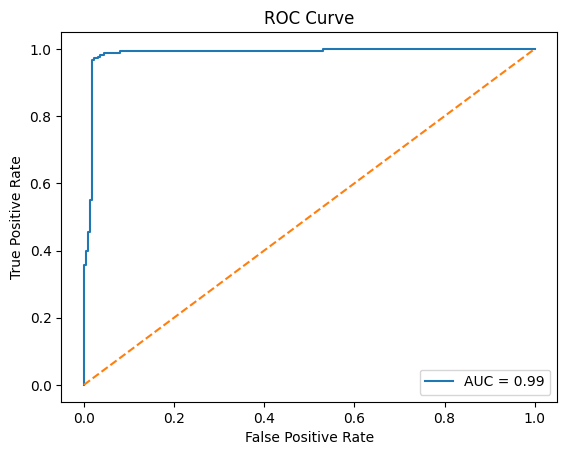

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = model.predict_proba(X_test_scaled)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

###Visualization Explanation

ROC Curve (Receiver Operating Characteristic Curve) shows the performance of a classification model at different thresholds.

X-axis → False Positive Rate (FPR)

Y-axis → True Positive Rate (TPR)

The diagonal line represents a random model
The actual curve shows how well the model performs compared to random guessing
### Output Explanation
The curve closer to the top-left corner indicates better model performance

AUC (Area Under Curve):

0.5 → Poor model (random)

0.7–0.8 → Good

0.8–0.9 → Very good

1.0 → Perfect